In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [3]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values


df.shape

(10015, 2353)

In [4]:
df.isnull().sum()

pixel0000    0
pixel0001    0
pixel0002    0
pixel0003    0
pixel0004    0
            ..
pixel2348    0
pixel2349    0
pixel2350    0
pixel2351    0
label        0
Length: 2353, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
X_train[1,:]

array([159, 105, 143, ..., 172, 118, 153], shape=(2352,))

In [7]:
df.head()


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [7]:
df.value_counts('label')

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64

In [8]:
df.shape

(10015, 2353)

Normalizing Images 


reshape(-1, 28, 28, 3) → reshapes your input data so that:

Each image is 28×28 pixels

Each pixel has 3 color channels (RGB)

-1 automatically infers the number of samples.

/ 255.0 → normalizes pixel values from 0–255 → 0–1 range.

In [8]:
X_train = X_train.reshape(-1, 28, 28, 3) 
X_test = X_test.reshape(-1, 28, 28, 3)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:


datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    # brightness_range=[0.6, 1.2],
    horizontal_flip=True
)

datagen.fit(X_train)


In [10]:
from tensorflow.keras import regularizers

#input shape (28 height , 28 width, 3 channels (RGB))

model = models.Sequential([
    #CNN operations
    #filters = number of feature detectors
    #kernel size = size of the feature detector 3x3
    #padding =  0; to keep the output size same as input size 

    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001), input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # layers.Conv2D(48,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    # layers.BatchNormalization(),
    # layers.Conv2D(48,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.2),
    
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.2),

    # layers.Conv2D(256, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.3),


    #ANN layers
    # flattening
    layers.GlobalAveragePooling2D(),

    # layers.Flatten(),
        
    # layers.Dense(256,activation='relu'),
    # layers.BatchNormalization(),
    # # layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    # layers.Dense(64,activation='relu'),
    # layers.BatchNormalization(),
    # layers.Dropout(0.3),
    # layers.Dense(32,activation='relu'),
    # layers.BatchNormalization(),
    # layers.Dropout(0.2),

    layers.Dense(7, activation='softmax')
])


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)


In [12]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [13]:
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),epochs=40,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/40


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - accuracy: 0.4881 - loss: 1.7177 - val_accuracy: 0.1378 - val_loss: 5.0750 - learning_rate: 3.0000e-04
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.6549 - loss: 1.2178 - val_accuracy: 0.6485 - val_loss: 1.3084 - learning_rate: 3.0000e-04
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.6897 - loss: 1.0277 - val_accuracy: 0.5786 - val_loss: 1.7880 - learning_rate: 3.0000e-04
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.7008 - loss: 0.9630 - val_accuracy: 0.6370 - val_loss: 1.1489 - learning_rate: 3.0000e-04
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.7037 - loss: 0.9260 - val_accuracy: 0.6725 - val_loss: 1.0492 - learning_rate: 3.0000e-04
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.7091 - loss: 0.9021 - val_accuracy: 0.6550 - val_loss: 1.1020 - learning_rate: 3.0000e-04
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - ac

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Training Accuracy:", model_prediction.history['accuracy'][-1])
print("Training Loss:", model_prediction.history['loss'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7329 - loss: 0.7939
Test Accuracy: 0.7329006195068359
Test Loss: 0.7938585877418518
Training Accuracy: 0.7738392353057861
Training Loss: 0.6933620572090149


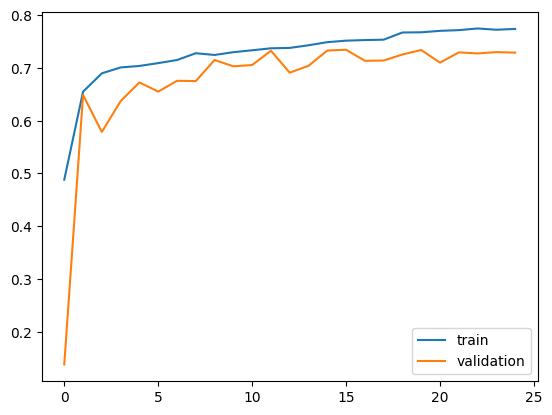

In [15]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

Roughly predicting 

In [23]:
from tensorflow.keras.preprocessing import image

image_path='C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\HAM10000_images_part_2\\ISIC_0029322.jpg'
img=image.load_img(image_path,target_size=(28,28))
img_array=image.img_to_array(img)
img_array= np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array=img_array/255.0


skin_disease=['Actinic keratoses','Basal cell carcinoma','Benign keratosis-like lesions','Dermatofibroma','Melanocytic nevi','Melanoma','Vascular lesions']
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

def explain_prediction(predicted_class):
    match predicted_class[0]:
        case 0:
            print("Precancerous lesions caused by chronic sun exposure.Usually rough, scaly, or crusty patches. Can develop into squamous cell carcinoma if untreated.")
        case 1:
            print("A common type of skin cancer that arises from basal cells in the epidermis. Often appears as pearly or waxy bumps, sometimes with visible blood vessels.")
        case 2:
            print("Non-cancerous skin growths that may appear as scaly, wart-like patches. They are usually benign but can be cosmetically concerning.")
        case 3:
            print("A benign skin tumor that appears as a firm, raised nodule. Often found on the limbs and can be itchy or tender.")
        case 4:
            print("Commonly known as moles, these are benign proliferations of melanocytes. They can vary in color and size and are usually harmless.")
        case 5:
            print("A serious form of skin cancer that originates in melanocytes. It can appear as an irregular mole or dark spot and has a high potential to spread if not detected early.")
        case 6:
            print("Benign growths of blood vessels that can appear as red or purple marks on the skin. They are usually harmless and may fade over time.")      



print("Predicted class:", skin_disease[predicted_class[0]])
explain_prediction(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted class: Melanocytic nevi
Commonly known as moles, these are benign proliferations of melanocytes. They can vary in color and size and are usually harmless.


Saving the model for deployment in web app

In [25]:
model.save('skin_disease_model.h5')